In [47]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
matplotlib.rcParams['font.size']    = 9

# Run from repo root or analysis/ — figures land in analysis/sup_figures/
_nb_dir = os.path.dirname(os.path.abspath('sarscov2_benchmark_viz.ipynb'))
FIG_DIR = os.path.join(_nb_dir, 'sup_figures')
os.makedirs(FIG_DIR, exist_ok=True)

In [48]:
# ── Load predictions and compute AUROC / AP ───────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

_repo    = os.path.dirname(os.path.dirname(os.path.abspath('sarscov2_benchmark_viz.ipynb')))
PRED_DIR = os.path.join(_repo, 'pred_results', 'SarsCov2')
DATA_DIR = os.path.join(_repo, 'data')

all_df = pd.read_csv(os.path.join(DATA_DIR, 'sarscov2_all.csv'))      # 858 rows
ns_df  = pd.read_csv(os.path.join(DATA_DIR, 'sarscov2_nonseen.csv'))  # 297 rows

def auroc_ap(df, score_col, negate=False):
    yp = df[score_col].values.astype(float) * (-1 if negate else 1)
    yt = df['Label'].values.astype(float)
    return roc_auc_score(yt, yp), average_precision_score(yt, yp)

def get_nonseen(df):
    return df.merge(ns_df[['Peptide', 'MHC']], on=['Peptide', 'MHC'], how='inner')

# ── ImmunoMTL (s44) ──────────────────────────────────────────────────────────
mtl      = pd.read_csv(os.path.join(PRED_DIR, 'sarscov2_MTL.csv'))
mtl_all  = auroc_ap(mtl, 'ImmunoMTL_score')
mtl_ns   = auroc_ap(get_nonseen(mtl), 'ImmunoMTL_score')

# ── BigMHC ────────────────────────────────────────────────────────────────────
bigmhc      = pd.read_csv(os.path.join(PRED_DIR, 'sarscov2_bigmhc.csv'))
bigmhc_all  = auroc_ap(bigmhc, 'BigMHC_IM')
bigmhc_ns   = auroc_ap(get_nonseen(bigmhc), 'BigMHC_IM')

# ── PRIME 2.0 ─────────────────────────────────────────────────────────────────
prime       = pd.read_csv(os.path.join(PRED_DIR, 'sarscov2_prime.csv'))
prime2r_all = auroc_ap(prime, 'PRIME_rank', negate=True)   # rank: lower=better
prime2r_ns  = auroc_ap(get_nonseen(prime), 'PRIME_rank', negate=True)
prime2s_all = auroc_ap(prime, 'PRIME_score')               # score: higher=better
prime2s_ns  = auroc_ap(get_nonseen(prime), 'PRIME_score')

# ── MUNIS ────────────────────────────────────────────────────────────────────
munis = pd.read_csv(os.path.join(PRED_DIR, 'sarscov2_all_munis_predictions.csv')
                    ).rename(columns={'pep': 'Peptide', 'mhc': 'MHC'})
munis_all   = auroc_ap(munis, 'score')
munis_ns    = auroc_ap(get_nonseen(munis), 'score')

# ── netMHCpan 4.1 (EL_Rank, lower=better) ────────────────────────────────────
netpan      = pd.read_csv(os.path.join(PRED_DIR, 'sarscov2_netMHCpan.csv'))
netpan_all  = auroc_ap(netpan, 'EL_Rank', negate=True)
netpan_ns   = auroc_ap(get_nonseen(netpan), 'EL_Rank', negate=True)

# ── MHCflurry 2.0 (presentation_percentile, lower=better) ────────────────────
mhcf        = pd.read_csv(os.path.join(PRED_DIR, 'sarscov2_mhcflurry.csv'))
mhcf_all    = auroc_ap(mhcf, 'mhcflurry_presentation_percentile', negate=True)
mhcf_ns     = auroc_ap(get_nonseen(mhcf), 'mhcflurry_presentation_percentile', negate=True)

# ── bbac141 raw: PRIME 1.0 and netMHCpan 4.0 ─────────────────────────────────
# ImmunogenicityScore for netMHCpan_EL ≈ EL-score (higher means better presenter
# but lower immunogenicity → lower=better for AUROC, negate=True)
bb = (pd.read_csv(os.path.join(PRED_DIR, 'benchmarkingextendeddata_bbac141_sarscov2.csv'))
        .rename(columns={'HLA_Allele': 'MHC'})
        .merge(all_df, on=['Peptide', 'MHC'], how='inner'))

prime1      = bb[bb.Dataset == 'PRIME']
prime1_all  = auroc_ap(prime1, 'ImmunogenicityScore')
prime1_ns   = auroc_ap(get_nonseen(prime1), 'ImmunogenicityScore')

net40       = bb[bb.Dataset == 'netMHCpan_EL']
net40_all   = auroc_ap(net40, 'ImmunogenicityScore', negate=True)
net40_ns    = auroc_ap(get_nonseen(net40), 'ImmunogenicityScore', negate=True)

# ── Assemble ──────────────────────────────────────────────────────────────────
MODELS = [
    ('MTL2',      'ImmunoMTL',      '#4E526E'),
    ('BigMHC',    'BigMHC',         '#F6D5A0'),
    ('PRIME1',    'PRIME1.0',       '#A8C0C2'),
    ('PRIME2s',   'PRIME2.0 Score', '#5A7A7D'),
    ('PRIME2',    'PRIME2.0 Rank',  '#718B8E'),
    ('MUNIS',     'MUNIS',          '#92BEAA'),
    ('netMHCpan', 'netMHCpan4.1',   '#606060'),
    ('MHCflurry', 'MHCflurry2.0',   '#F0C3AF'),
]

DATA = {
    'all': {
        'MTL2':       {'auroc': mtl_all[0],     'ap': mtl_all[1]},
        'BigMHC':     {'auroc': bigmhc_all[0],  'ap': bigmhc_all[1]},
        'PRIME1':     {'auroc': prime1_all[0],  'ap': prime1_all[1]},
        'PRIME2s':    {'auroc': prime2s_all[0], 'ap': prime2s_all[1]},
        'PRIME2':     {'auroc': prime2r_all[0], 'ap': prime2r_all[1]},
        'MUNIS':      {'auroc': munis_all[0],   'ap': munis_all[1]},
        'netMHCpan':  {'auroc': netpan_all[0],  'ap': netpan_all[1]},
        'MHCflurry':  {'auroc': mhcf_all[0],    'ap': mhcf_all[1]},
    },
    'nonseen': {
        'MTL2':       {'auroc': mtl_ns[0],     'ap': mtl_ns[1]},
        'BigMHC':     {'auroc': bigmhc_ns[0],  'ap': bigmhc_ns[1]},
        'PRIME1':     {'auroc': prime1_ns[0],  'ap': prime1_ns[1]},
        'PRIME2s':    {'auroc': prime2s_ns[0], 'ap': prime2s_ns[1]},
        'PRIME2':     {'auroc': prime2r_ns[0], 'ap': prime2r_ns[1]},
        'MUNIS':      {'auroc': munis_ns[0],   'ap': munis_ns[1]},
        'netMHCpan':  {'auroc': netpan_ns[0],  'ap': netpan_ns[1]},
        'MHCflurry':  {'auroc': mhcf_ns[0],    'ap': mhcf_ns[1]},
    },
}

TRAIN_OVERLAP_PCT = 65.4
N_ALL = len(all_df)   # 858
N_NS  = len(ns_df)    # 297

print(f"{'Model':16s}  {'AUROC-all':>10s}  {'AP-all':>8s}  {'AUROC-ns':>10s}  {'AP-ns':>8s}")
print('-' * 62)
for tag, label, _ in MODELS:
    d = DATA['all'][tag]; dn = DATA['nonseen'][tag]
    print(f"{label:16s}  {d['auroc']:10.4f}  {d['ap']:8.4f}  {dn['auroc']:10.4f}  {dn['ap']:8.4f}")


Model              AUROC-all    AP-all    AUROC-ns     AP-ns
--------------------------------------------------------------
ImmunoMTL             0.7369    0.7964      0.6696    0.6646
BigMHC                0.4878    0.6344      0.6009    0.5881
PRIME1.0              0.5199    0.6546      0.5601    0.5907
PRIME2.0 Score        0.5152    0.6579      0.5720    0.6221
PRIME2.0 Rank         0.4957    0.6435      0.5340    0.5826
MUNIS                 0.4907    0.6360      0.4672    0.5434
netMHCpan4.1          0.4631    0.6355      0.4790    0.5700
MHCflurry2.0          0.4974    0.6566      0.5816    0.6282


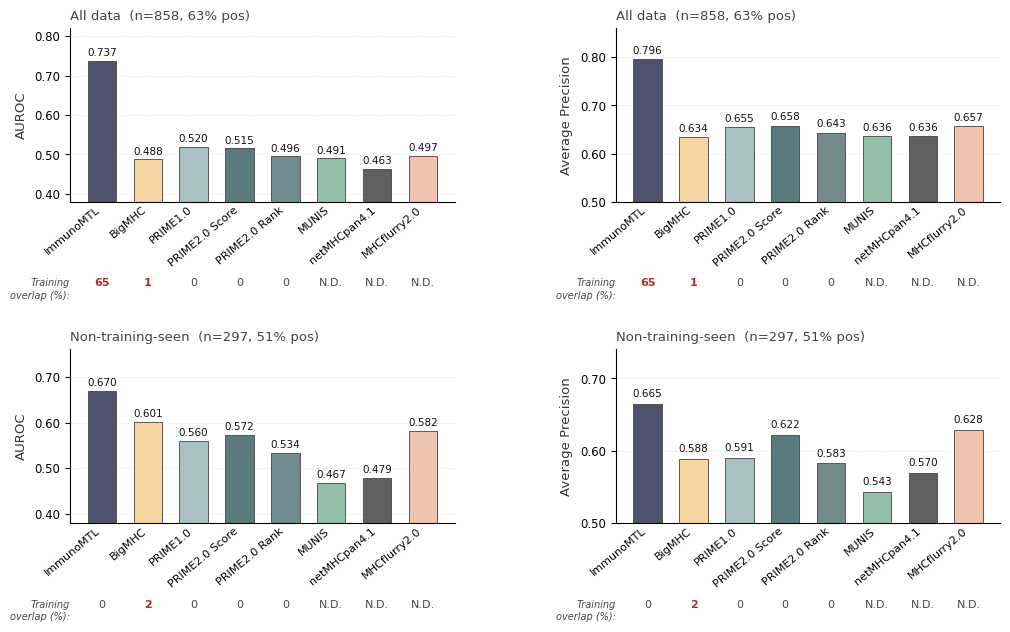

Saved → analysis/sup_figures/sarscov2_benchmark.{pdf,png}


In [51]:
# ── Four-panel figure: 2 splits × 2 metrics  (journal style) ─────────────────
from matplotlib.transforms import blended_transform_factory

n  = len(MODELS)
x  = np.arange(n)
bw = 0.62

# Training overlap per split: ImmunoMTL training data; BigMHC/PRIME2 from their published sets
OVERLAPS = {
    'all':     {'MTL2': 65.4, 'BigMHC': 0.9, 'PRIME2': 0, 'PRIME1': 0, 'PRIME2s': 0, 'MUNIS': None, 'netMHCpan': None, 'MHCflurry': None},
    'nonseen': {'MTL2': 0,    'BigMHC': 2.0,  'PRIME2': 0, 'PRIME1': 0, 'PRIME2s': 0, 'MUNIS': None, 'netMHCpan': None, 'MHCflurry': None},
}

# n=858: 540 pos (63%); n=297: 152 pos (51%)
PANELS = [
    (0, 0, 'all',     'auroc', f'All data  (n={N_ALL}, 63% pos)',         'AUROC'),
    (0, 1, 'all',     'ap',    f'All data  (n={N_ALL}, 63% pos)',         'Average Precision'),
    (1, 0, 'nonseen', 'auroc', f'Non-training-seen  (n={N_NS}, 51% pos)', 'AUROC'),
    (1, 1, 'nonseen', 'ap',    f'Non-training-seen  (n={N_NS}, 51% pos)', 'Average Precision'),
]

YLIM = {
    'all':     {'auroc': (0.38, 0.82), 'ap': (0.50, 0.86)},
    'nonseen': {'auroc': (0.38, 0.76), 'ap': (0.50, 0.74)},
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
fig.subplots_adjust(hspace=0.85, wspace=0.42, bottom=0.18, top=0.84)

for idx, (row, col, split_key, metric_key, split_title, ylabel) in enumerate(PANELS):
    ax = axes[row, col]

    for i, (tag, label, color) in enumerate(MODELS):
        val = DATA[split_key][tag][metric_key]
        ax.bar(i, val, width=bw, color=color, edgecolor='#444444', linewidth=0.6)
        ax.text(i, val + 0.007, f'{val:.3f}',
                ha='center', va='bottom', fontsize=7.5, color='#111111', fontweight='normal')

    # Title and y-axis label
    ax.set_title(split_title, fontsize=9.5, loc='left', pad=6, color='#444444')
    ax.set_ylabel(ylabel, fontsize=9.5, labelpad=5, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels([m[1] for m in MODELS], rotation=40, ha='right', fontsize=8)
    ax.tick_params(axis='x', length=0, pad=2)
    ax.set_ylim(*YLIM[split_key][metric_key])
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.10))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='y', labelsize=8.5, width=0.8)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
    ax.set_axisbelow(True)

    # ── Overlap row below every panel ─────────────────────────────────────────
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(-0.7, -0.44, 'Training\noverlap (%):', transform=trans,
            ha='right', va='top', fontsize=7, color='#464646',
            style='italic', linespacing=1.3)
    for i, (tag, label, color) in enumerate(MODELS):
        ov = OVERLAPS[split_key][tag]
        if ov is not None and ov > 0:
            txt, fc, fw = f'{ov:.0f}', '#B03020', 'bold'
        elif ov == 0:
            txt, fc, fw = '0', '#464646', 'normal'
        else:
            txt, fc, fw = 'N.D.', '#464646', 'normal'
        ax.text(i, -0.44, txt, transform=trans,
                ha='center', va='top', fontsize=8, color=fc, fontweight=fw)

#fig.suptitle('SARS-CoV-2 immunogenicity benchmark', fontsize=12,
#             fontweight='bold', y=0.96, color='#111111')

plt.savefig(os.path.join(FIG_DIR, 'sarscov2_benchmark.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'sarscov2_benchmark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → analysis/sup_figures/sarscov2_benchmark.{pdf,png}')
